In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import cv2
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

/home/mlguest/miniforge3/envs/torch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_path = "meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"

train_df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, dataset_path, "Train.csv")
test_df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, dataset_path, "Test.csv")
cache_path = kagglehub.dataset_download(dataset_path)

In [3]:
def get_image(img_path):
    paths = [
        os.path.join(cache_path, img_path),
        os.path.join(cache_path, 'Train', img_path),
        os.path.join(cache_path, 'Test', img_path),
    ]
    
    for path in paths:
        if os.path.exists(path):
            img = cv2.imread(path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (32, 32))
                img = img.astype('float32') / 255.0
                return img
    return None

In [4]:
X, y = [], []
for _, row in train_df.iterrows():
    img = get_image(row['Path'])
    if img is not None:
        X.append(img)
        y.append(row['ClassId'])

X = np.array(X)
y = np.array(y)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [6]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
num_classes = len(le.classes_)

In [7]:
X_train = torch.tensor(X_train).permute(0, 3, 1, 2)
X_test = torch.tensor(X_test).permute(0, 3, 1, 2)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)

In [8]:
class Model(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1, stride=2)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout(0.25)
        
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 64, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        self.fc1 = nn.Linear(64 * 2 * 2, 128)
        self.fc2 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        x = self.drop(self.pool(self.bn1(F.relu(self.conv1(x)))))
        x = self.drop(self.pool(self.bn2(F.relu(self.conv2(x)))))
        x = self.drop(self.pool(self.bn3(F.relu(self.conv3(x)))))
        x = x.reshape(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)

model = Model(num_classes)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_accs, val_accs = [], []

for epoch in range(10):
    model.train()
    correct, total = 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        _, pred = torch.max(out, 1)
        total += y.size(0)
        correct += (pred == y).sum().item()
    
    train_acc = 100 * correct / total
    train_accs.append(train_acc)
    
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            _, pred = torch.max(out, 1)
            total += y.size(0)
            correct += (pred == y).sum().item()
    
    val_acc = 100 * correct / total
    val_accs.append(val_acc)

print(f"\nTest Accuracy: {val_acc:.2f}%")


Test Accuracy: 97.50%



Слой: conv1, Форма: (1, 32, 16, 16)


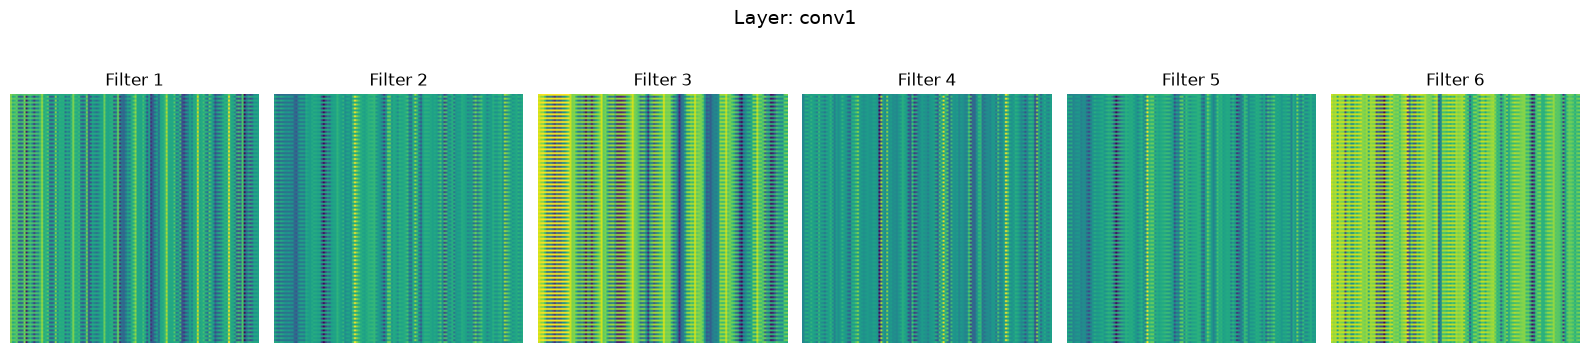


Слой: conv2, Форма: (1, 64, 8, 8)


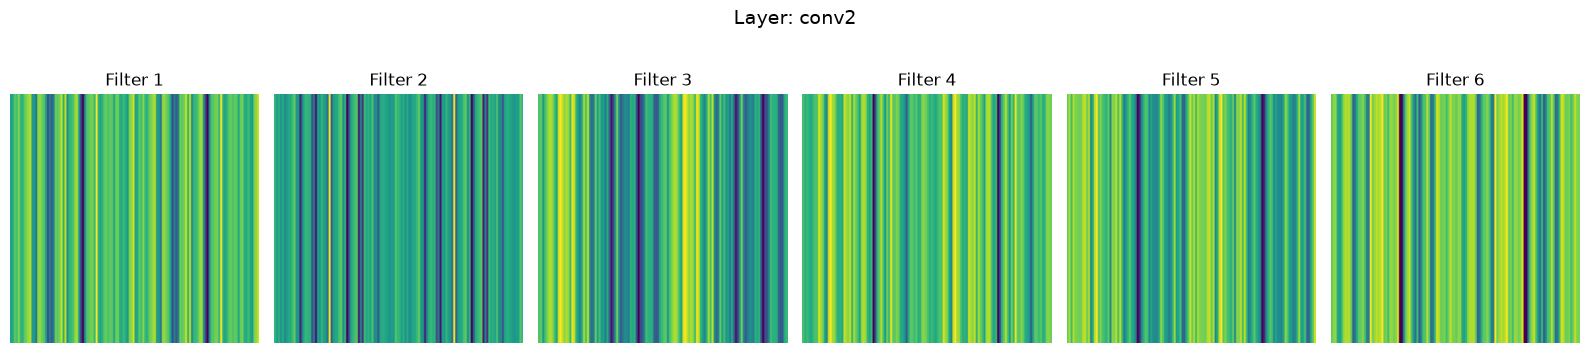


Слой: conv3, Форма: (1, 64, 4, 4)


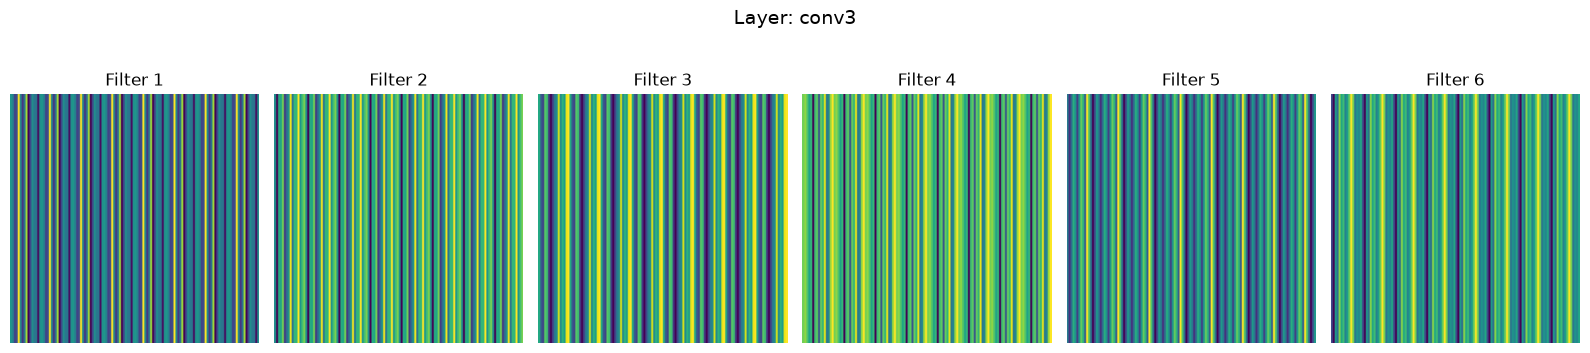

In [10]:
img = X_train[0:1].to(device)
activations = {}

def hook_fn(name):
    def hook(module, input, output):
        activations[name] = output.detach().cpu().numpy()
    return hook

hooks = []
for name, layer in model.named_modules():
    if 'conv' in name and isinstance(layer, nn.Conv2d):
        hooks.append(layer.register_forward_hook(hook_fn(name)))

with torch.no_grad():
    _ = model(img)

for hook in hooks:
    hook.remove()

for name, act in activations.items():
    print(f"\nСлой: {name}, Форма: {act.shape}")
    
    n_filters = min(6, act.shape[1])
    fig, axes = plt.subplots(1, n_filters, figsize=(16, 4))
    fig.suptitle(f'Layer: {name}', fontsize=14)
    
    for i in range(n_filters):
        channel = act[0, i, :, :]
        channel = np.resize(channel, (128, 128))
        axes[i].imshow(channel, cmap='viridis')
        axes[i].set_title(f'Filter {i+1}')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()